### This notebook will examine the similarities between NNLS and Ridge predictions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nb
import SUITPy as suit
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as ccs
import cortico_cereb_connectivity.evaluation as ev
import Functional_Fusion.atlas_map as am

/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


#### Load global models

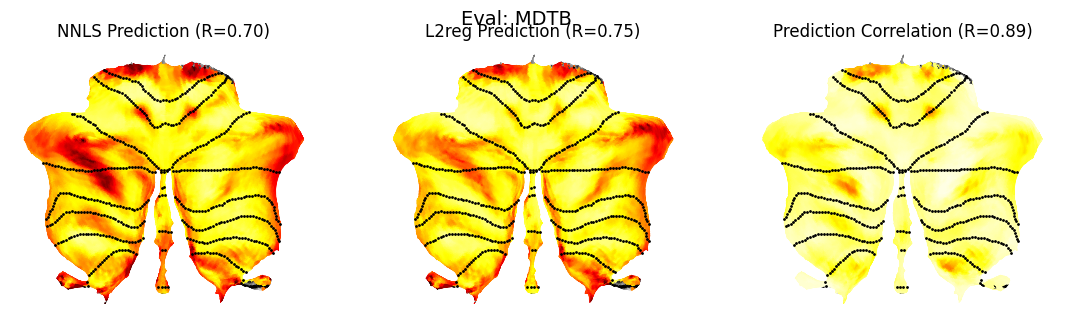

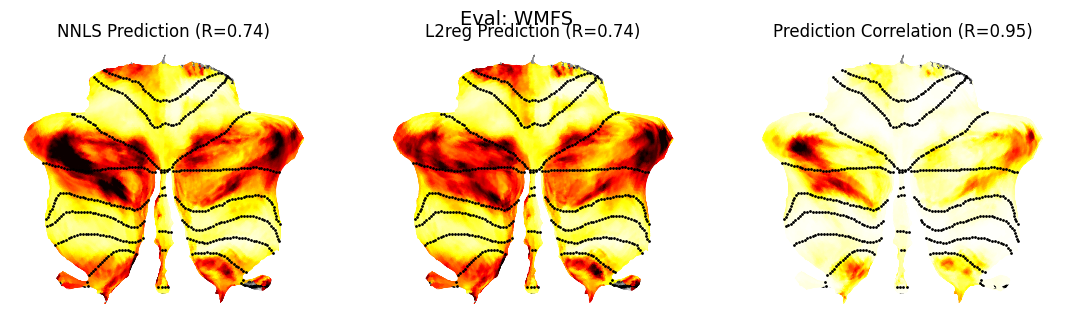

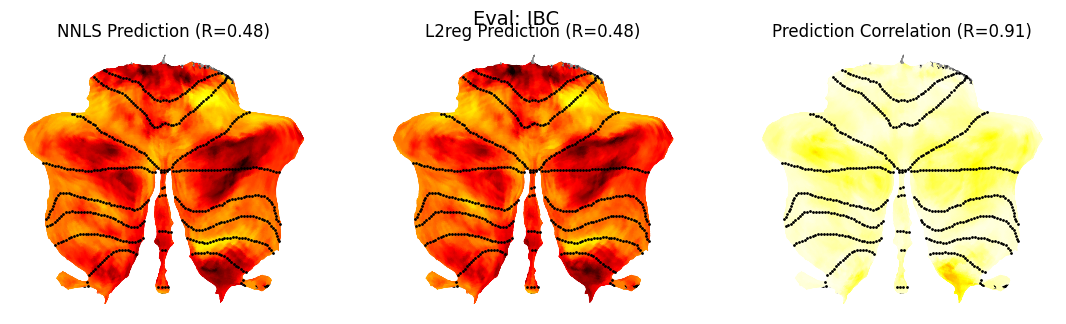

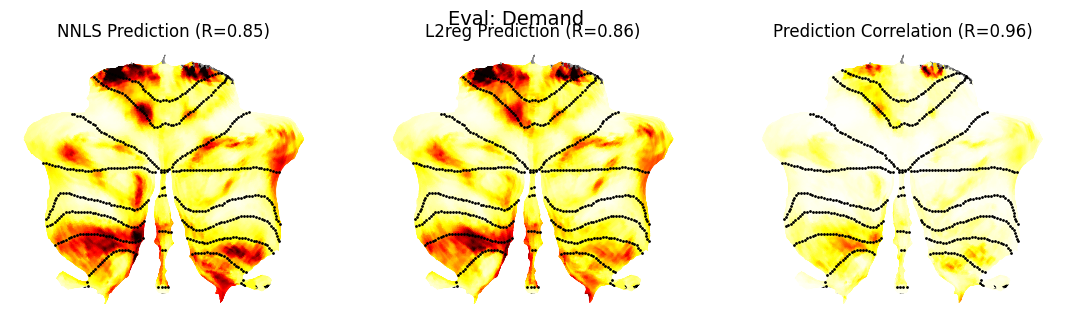

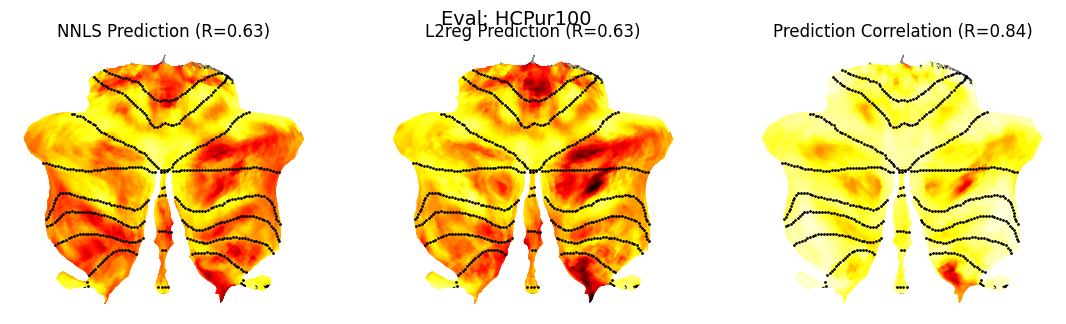

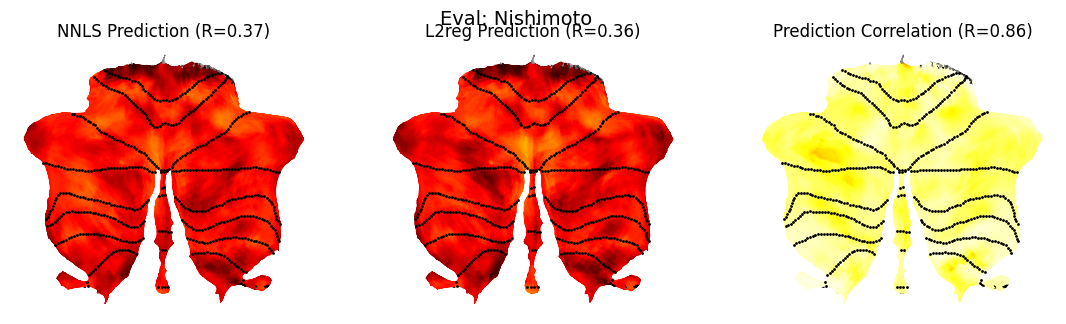

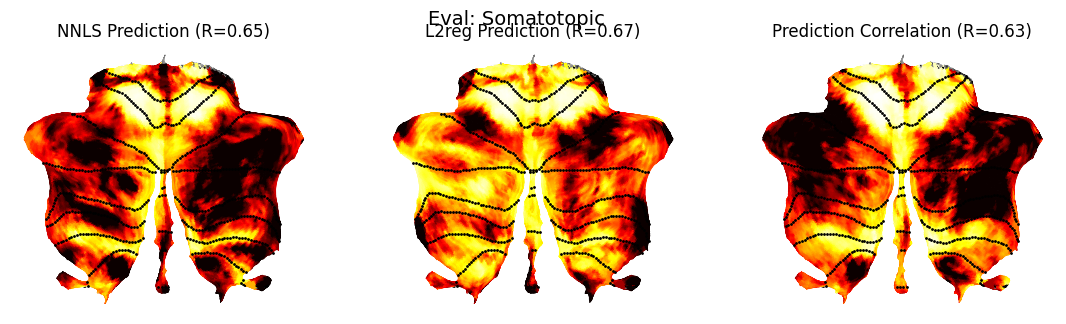

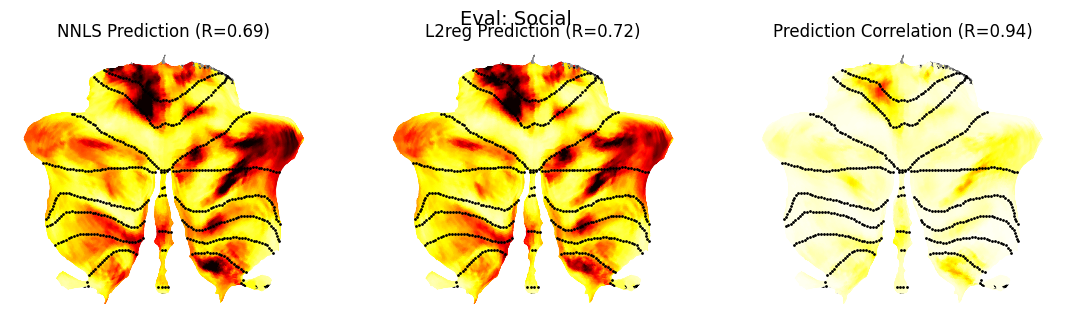

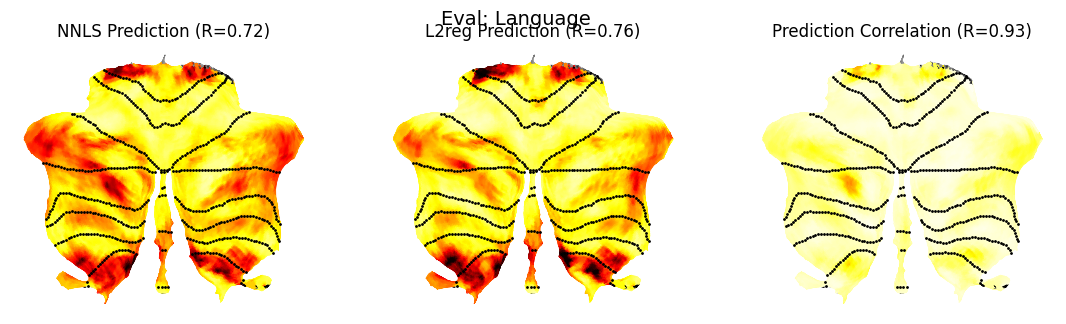

In [5]:
atlas, _ = am.get_atlas('MNISymC3')

train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets

extention_list_1 = ["A1_global", "A0_global", "A1_global", "A1_global", "A0_global", "A1_global", "global", "A2_global", "A0_global"]
extention_list_2 = ["A2_global", "A2_global", "A4_global", "A2_global", "A2_global", "A4_global", "A0_global", "A2_global", "A2_global"]

R_NNLS_list = []
R_L2reg_list = []
R_vox_NNLS_list = []
R_vox_L2reg_list = []
R_pred_list = []
R_vox_pred_list = []

for t, (traindata, ext1, ext2) in enumerate(zip(train_ds_list, extention_list_1, extention_list_2)):
    # load model
    model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', ext1, cerebellum_atlas="MNISymC3")
    model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', ext2, cerebellum_atlas="MNISymC3")

    # load data
    X = nb.load(f'{gl.conn_dir}/maps/{eval_ds_list[t]}_data_cortex.pscalar.nii').get_fdata()
    Y = nb.load(f'{gl.conn_dir}/maps/{eval_ds_list[t]}_data_cerebellum.dscalar.nii').get_fdata()
    # cereb_data = suit.vol_to_surf(atlas.data_to_nifti(Y), space='MNISymC')

    # make predictions
    Y_pred_NNLS = model_NNLS.predict(X)
    Y_pred_L2reg = model_L2reg.predict(X)

    # prediction corr
    R_pred, R_vox_pred = ev.calculate_R(Y_pred_L2reg, Y_pred_NNLS)
    R_vox_pred_data = suit.vol_to_surf(atlas.data_to_nifti(R_vox_pred), space='MNISymC')

    # calculate R
    R_NNLS, R_vox_NNLS = ev.calculate_R(Y, Y_pred_NNLS)
    R_vox_NNLS_data = suit.vol_to_surf(atlas.data_to_nifti(R_vox_NNLS), space='MNISymC')
    R_L2reg, R_vox_L2reg = ev.calculate_R(Y, Y_pred_L2reg)
    R_vox_L2reg_data = suit.vol_to_surf(atlas.data_to_nifti(R_vox_L2reg), space='MNISymC')

    # add to list
    R_NNLS_list.append(R_NNLS)
    R_L2reg_list.append(R_L2reg)
    R_vox_NNLS_list.append(R_vox_NNLS)
    R_vox_L2reg_list.append(R_vox_L2reg)
    R_pred_list.append(R_pred)
    R_vox_pred_list.append(R_vox_pred)

    # plot
    plt.subplots(1, 3, figsize=(13.5, 3.5))
    plt.suptitle(f'Eval: {eval_ds_list[t]}', fontsize=14)
    plt.subplot(1, 3, 1)
    suit.flatmap.plot(R_vox_NNLS_data, cmap='hot', new_figure=False, cscale=[0, 1])
    plt.title(f'NNLS Prediction (R={R_NNLS:.2f})')
    plt.subplot(1, 3, 2)
    suit.flatmap.plot(R_vox_L2reg_data, cmap='hot', new_figure=False, cscale=[0, 1])
    plt.title(f'L2reg Prediction (R={R_L2reg:.2f})')
    plt.subplot(1, 3, 3)
    suit.flatmap.plot(R_vox_pred_data, cmap='hot', new_figure=False, cscale=[0, 1])
    plt.title(f'Prediction Correlation (R={R_pred:.2f})')
    plt.show()

#### Mean across datasets

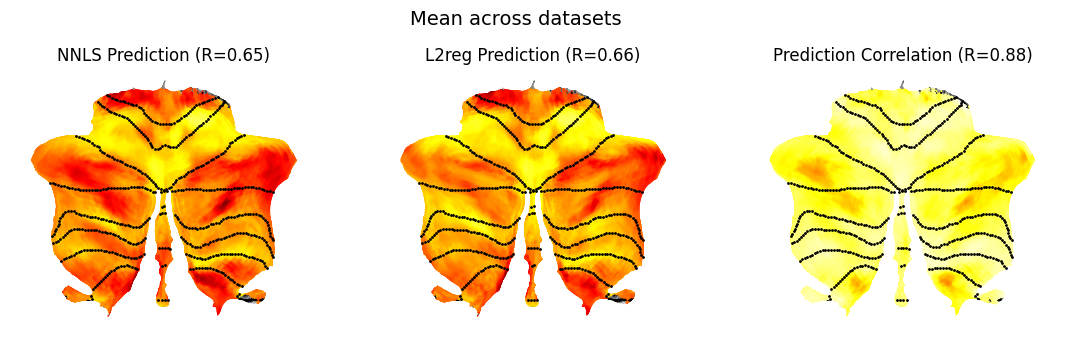

In [9]:
R_vox_NNLS_list_data = suit.vol_to_surf(atlas.data_to_nifti(np.array(R_vox_NNLS_list).mean(axis=0)), space='MNISymC')
R_vox_L2reg_list_data = suit.vol_to_surf(atlas.data_to_nifti(np.array(R_vox_L2reg_list).mean(axis=0)), space='MNISymC')
R_vox_pred_list_data = suit.vol_to_surf(atlas.data_to_nifti(np.array(R_vox_pred_list).mean(axis=0)), space='MNISymC')

fig, _ = plt.subplots(1, 3, figsize=(13.5, 3.5))
fig.suptitle('Mean across datasets', fontsize=14, y=1.02)
plt.subplots_adjust(top=0.85)
plt.subplot(1, 3, 1)
suit.flatmap.plot(R_vox_NNLS_list_data, cmap='hot', new_figure=False, cscale=[0, 1])
plt.title(f'NNLS Prediction (R={np.array(R_NNLS_list).mean():.2f})')
plt.subplot(1, 3, 2)
suit.flatmap.plot(R_vox_L2reg_list_data, cmap='hot', new_figure=False, cscale=[0, 1])
plt.title(f'L2reg Prediction (R={np.array(R_L2reg_list).mean():.2f})')
plt.subplot(1, 3, 3)
suit.flatmap.plot(R_vox_pred_list_data, cmap='hot', new_figure=False, cscale=[0, 1])
plt.title(f'Prediction Correlation (R={np.array(R_pred_list).mean():.2f})')
plt.show()

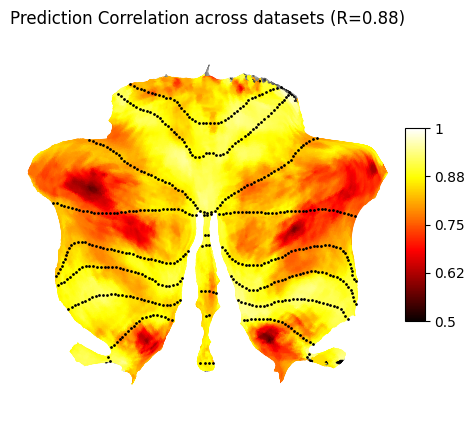

In [13]:
plt.figure(figsize=(6,5))
plt.title(f'Prediction Correlation across datasets (R={np.array(R_pred_list).mean():.2f})');
suit.flatmap.plot(R_vox_pred_list_data, cmap='hot', new_figure=False, colorbar=True, cscale=[0.5, 1]);

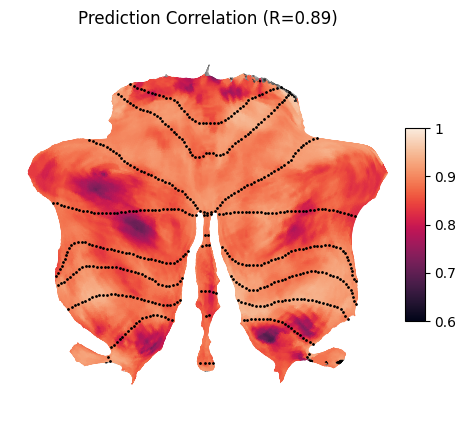

In [ ]:
atlas, _ = am.get_atlas('MNISymC3')
traindata = ''.join(gl.dscode)

model_NNLS, _ = ccs.get_model(traindata, 'Icosahedron1002', 'NNLS', "A0_global", cerebellum_atlas="MNISymC3")
model_L2reg, _ = ccs.get_model(traindata, 'Icosahedron1002', 'L2reg', "A2_global", cerebellum_atlas="MNISymC3")

# load data
X = nb.load(f'{gl.conn_dir}/maps/{traindata}_data_cortex.pscalar.nii').get_fdata()

# make predictions
Y_pred_NNLS = model_NNLS.predict(X)
Y_pred_L2reg = model_L2reg.predict(X)

# prediction corr
R_pred, R_vox_pred = ev.calculate_R(Y_pred_L2reg, Y_pred_NNLS)
R_vox_pred_data = suit.vol_to_surf(atlas.data_to_nifti(R_vox_pred), space='MNISymC')

plt.figure(figsize=(6,5))
plt.title(f'Prediction Correlation (R={R_pred:.2f})');
suit.flatmap.plot(R_vox_pred_data, cmap='rocket', new_figure=False, colorbar=True, cscale=[0.6, 1]);